# Satellite Image Classification and Deforestation Detection

This notebook trains a ResNet50 transfer-learning classifier on the EuroSAT land-cover dataset,
then applies it to real Sentinel-2 imagery of Rondônia, Brazil to detect land-cover change
between 2018 and 2024. Results are validated against Global Forest Watch's independently
published tree-cover-loss data.

**Note:** this notebook must be run top-to-bottom in Google Colab to regenerate real outputs.
Requires: a Kaggle API token, a Google Earth Engine account with a registered Cloud project,
and a T4 GPU runtime for the training sections (CPU is sufficient, but slower, for the
inference-only sections later in the notebook).

## 1. Environment Setup

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


## 2. Dataset Download & Verification

Downloads the EuroSAT RGB dataset from Kaggle. Requires a Kaggle API token
(`kaggle.json` or the newer access-token flow) uploaded/configured beforehand.

**Verification note:** this Kaggle mirror bundles both the 13-band multispectral version
(`EuroSATallBands/`, `.tif` files) and the plain RGB version (`EuroSAT/`, `.jpg` files).
We use the RGB folder — confirmed below.

In [2]:
import os

if not os.path.exists('EuroSAT_data/EuroSAT'):
    !pip install kaggle
    !kaggle datasets download -d apollo2506/eurosat-dataset
    !unzip -q eurosat-dataset.zip -d EuroSAT_data
else:
    print("Dataset already present, skipping download.")

# Verify we're pointing at the RGB JPEG folder, not the multispectral TIFF folder
print(os.listdir('EuroSAT_data/EuroSAT/Forest')[:3])

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:23<00:00, 95.0MB/s]

['Forest_706.jpg', 'Forest_2102.jpg', 'Forest_2665.jpg']


## 3. Data Pipeline

Builds train/val/test transforms (resize to 224x224 for ResNet50, ImageNet normalization,
random flips for training augmentation only), then splits the dataset 80/10/10 using a fixed
random seed for reproducibility. Two separate `ImageFolder` instances (one per transform) are
split with identical indices, so validation and test sets never receive training augmentation.

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader, Subset

data_root = 'EuroSAT_data/EuroSAT'

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

full_dataset = datasets.ImageFolder(root=data_root)
class_names = full_dataset.classes  # alphabetical order, e.g. AnnualCrop=0, Forest=1, ...
print("Classes:", class_names)
print("Total images:", len(full_dataset))

generator = torch.Generator().manual_seed(42)
full_size = len(full_dataset)
train_size = int(0.8 * full_size)
val_size = int(0.1 * full_size)
test_size = full_size - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(full_size), [train_size, val_size, test_size], generator=generator
)

train_dataset_full = datasets.ImageFolder(root=data_root, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(root=data_root, transform=eval_transform)

train_set = Subset(train_dataset_full, train_indices.indices)
val_set = Subset(eval_dataset_full, val_indices.indices)
test_set = Subset(eval_dataset_full, test_indices.indices)

print(len(train_set), len(val_set), len(test_set))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images: 27000
21600 2700 2700


## 4. Model: ResNet50 with Transfer Learning

Loads ImageNet-pretrained ResNet50, freezes every layer, and replaces the final
classification layer (2048 -> 1000) with a new one sized for our 10 EuroSAT classes
(2048 -> 10). Only this new layer is trainable in Phase 1.

`device` is detected automatically - uses GPU if available, falls back to CPU otherwise
(training on CPU is impractically slow; if this prints `cpu`, reconnect with a GPU runtime
before running the training cells below).

In [4]:
import torchvision.models as models
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
model = model.to(device)

print(model.fc)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


Linear(in_features=2048, out_features=10, bias=True)


## 5. Load Existing Checkpoint, or Train From Scratch

Mounts Drive and checks for an already-trained checkpoint first — since a trained model
(98.56% validation accuracy) already exists from this project's original run, there is no
need to retrain unless the checkpoint is missing or you want to reproduce training from
scratch. Set `FORCE_RETRAIN = True` below to retrain anyway.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
import torch.optim as optim

drive_checkpoint_path = '/content/drive/MyDrive/best_model.pth'
local_checkpoint_path = 'best_model.pth'
FORCE_RETRAIN = False

criterion = nn.CrossEntropyLoss()

if os.path.exists(drive_checkpoint_path) and not FORCE_RETRAIN:
    shutil.copy(drive_checkpoint_path, local_checkpoint_path)
    checkpoint = torch.load(local_checkpoint_path, map_location=torch.device(device))
    model.load_state_dict(checkpoint['model_state_dict'])
    best_val_accuracy = checkpoint['val_accuracy']
    print(f"Loaded existing checkpoint from Drive — val accuracy: {best_val_accuracy:.4f}. Skipping training.")
    SKIP_TRAINING = True
else:
    best_val_accuracy = 0.0
    SKIP_TRAINING = False
    print("No existing checkpoint found (or FORCE_RETRAIN=True) — will train from scratch below.")

Mounted at /content/drive
Loaded existing checkpoint from Drive — val accuracy: 0.9856. Skipping training.


## 6. Phase 1 — Frozen-Layer Training

Trains only the new final layer for 10 epochs (skipped automatically if a checkpoint was
already loaded above). Checkpointing saves the model's weights plus its validation accuracy
every time validation accuracy improves, so the best epoch is preserved even if a later
epoch performs worse.

In [6]:
if not SKIP_TRAINING:
    optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
    num_epochs = 10

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save({'model_state_dict': model.state_dict(), 'val_accuracy': val_accuracy}, local_checkpoint_path)
            print(f'  -> New best model saved (Val Accuracy: {val_accuracy:.4f})')
else:
    print("Skipped — using loaded checkpoint.")

Skipped — using loaded checkpoint.


## 7. Phase 2 — Fine-Tuning (All Layers Unfrozen)

Unfreezes the entire network and continues training at a 10x lower learning rate (0.0001
vs 0.001), allowing the earlier convolutional layers to adapt slightly to satellite imagery
without erasing their pretrained ImageNet features. Also skipped if a checkpoint was already
loaded above.

In [7]:
if not SKIP_TRAINING:
    for param in model.parameters():
        param.requires_grad = True

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    num_epochs = 10

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = correct / total
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_accuracy:.4f}')

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save({'model_state_dict': model.state_dict(), 'val_accuracy': val_accuracy}, local_checkpoint_path)
            print(f'  -> New best model saved (Val Accuracy: {val_accuracy:.4f})')

    shutil.copy(local_checkpoint_path, drive_checkpoint_path)
    print("Final best model backed up to Drive.")
else:
    print("Skipped — using loaded checkpoint.")

Skipped — using loaded checkpoint.


## 8. Test Set Evaluation

Loads the best checkpoint and evaluates on the held-out test set (never used during training
or checkpoint selection). Reports per-class precision/recall/F1 and a row-normalized
confusion matrix.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.99      0.97       300
              Forest       1.00      0.99      0.99       297
HerbaceousVegetation       0.98      0.98      0.98       302
             Highway       0.99      0.98      0.98       269
          Industrial       0.97      0.99      0.98       257
             Pasture       0.97      0.97      0.97       187
       PermanentCrop       0.98      0.96      0.97       254
         Residential       1.00      0.99      0.99       314
               River       0.99      0.98      0.98       245
             SeaLake       0.99      0.99      0.99       275

            accuracy                           0.98      2700
           macro avg       0.98      0.98      0.98      2700
        weighted avg       0.98      0.98      0.98      2700



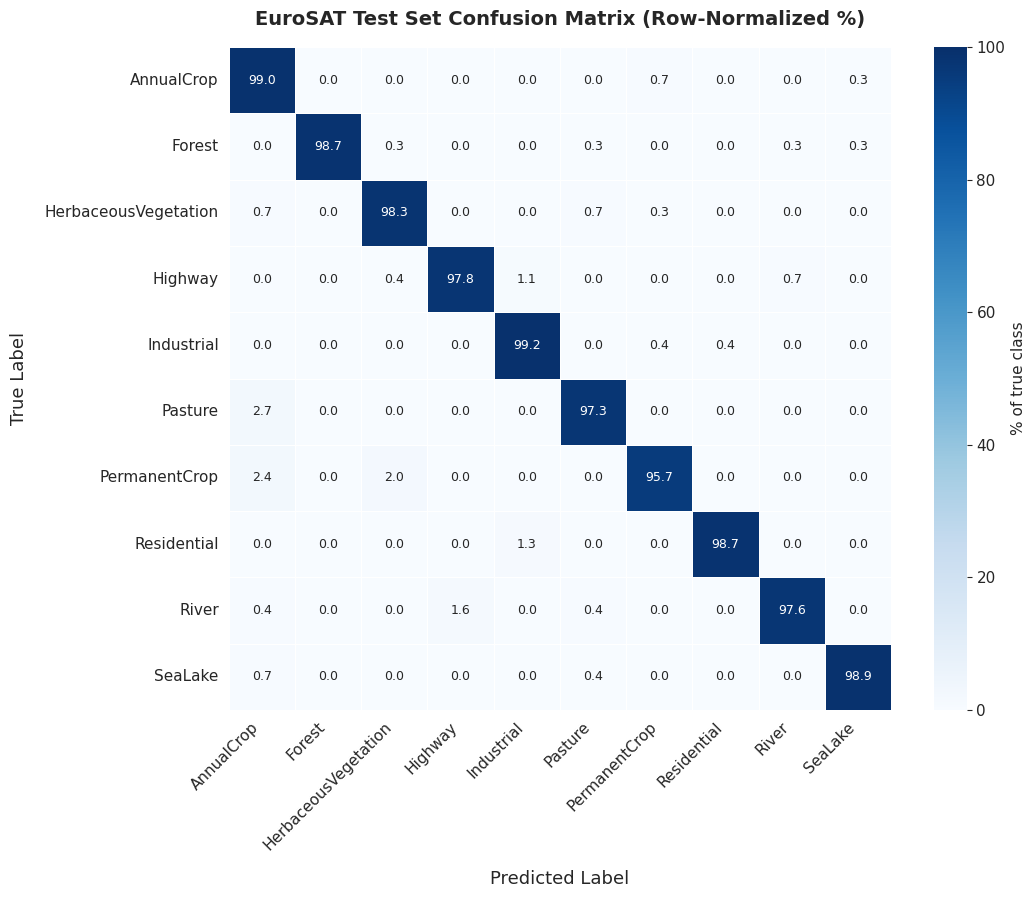

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm_normalized, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    cbar_kws={'label': '% of true class'}, linewidths=0.5, linecolor='white',
    square=True, vmin=0, vmax=100, annot_kws={'size': 9}
)
ax.set_xlabel('Predicted Label', fontsize=13, labelpad=12)
ax.set_ylabel('True Label', fontsize=13, labelpad=12)
ax.set_title('EuroSAT Test Set Confusion Matrix (Row-Normalized %)', fontsize=14, pad=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 9. Deforestation Detection: Earth Engine Setup

Authenticates Google Earth Engine (requires a registered noncommercial account and a Cloud
project with the Earth Engine API enabled — see `code.earthengine.google.com/register`) and
defines the study area: a ~111km x 111km region in Rondônia, Brazil, along the BR-364
highway corridor, chosen for its well-documented land-cover change and strong Global Forest
Watch data coverage.

In [11]:
import ee

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='research-project-507108')

aoi = ee.Geometry.Rectangle([-63.0, -10.5, -62.0, -9.5])
print("AOI defined:", aoi.getInfo())

AOI defined: {'type': 'Polygon', 'coordinates': [[[-63, -10.5], [-62, -10.5], [-62, -9.5], [-63, -9.5], [-63, -10.5]]]}


## 10. Cloud-Filtered Composites & Export

Builds cloud-masked median composites for the dry-season months (June-September, when cloud
cover is lowest in this region) of 2018 and 2024, then exports both as GeoTIFFs to Google
Drive. Pixel values are rescaled from raw reflectance to a standard 0-255 byte range to match
what the classifier expects.

In [12]:
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000)

def build_composite(year_start, year_end, aoi):
    collection = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(year_start, year_end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2_clouds)
    )
    composite = collection.median().clip(aoi)
    rgb = composite.select(['B4', 'B3', 'B2'])
    return rgb, collection.size().getInfo()

rgb_2018, n_2018 = build_composite('2018-06-01', '2018-09-30', aoi)
rgb_2024, n_2024 = build_composite('2024-06-01', '2024-09-30', aoi)
print(f"Images used — 2018: {n_2018}, 2024: {n_2024}")

Images used — 2018: 30, 2024: 115


In [13]:
task_2018 = ee.batch.Export.image.toDrive(
    image=rgb_2018.multiply(255).toByte(),
    description='rondonia_2018_export', folder='deforestation_project',
    fileNamePrefix='rondonia_2018', region=aoi, scale=10, maxPixels=1e9
)
task_2024 = ee.batch.Export.image.toDrive(
    image=rgb_2024.multiply(255).toByte(),
    description='rondonia_2024_export', folder='deforestation_project',
    fileNamePrefix='rondonia_2024', region=aoi, scale=10, maxPixels=1e9
)
task_2018.start()
task_2024.start()

import time
while task_2018.active() or task_2024.active():
    print(f"2018: {task_2018.status()['state']} | 2024: {task_2024.status()['state']}")
    time.sleep(15)

print("Both exports finished.")

2018: READY | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: READY
2018: RUNNING | 2024: 

## 11. Load Exported Imagery & Extract Patches

Downloads/reads the two GeoTIFFs (manually retrieved from the Earth Engine account's Drive —
see README for details on the account-mismatch workaround used in this project) and extracts
64x64 patches matching EuroSAT's native patch size and Sentinel-2's 10m/pixel resolution.

A random sample (not every possible patch) is used for computational tractability, with a
fixed seed so the same physical locations are compared across both years.

In [14]:
import rasterio
import numpy as np
import random

with rasterio.open('/content/drive/MyDrive/deforestation_project/rondonia_2018.tif') as src:
    img_2018 = src.read()
with rasterio.open('/content/drive/MyDrive/deforestation_project/rondonia_2024.tif') as src:
    img_2024 = src.read()

print("2018 shape:", img_2018.shape, "| 2024 shape:", img_2024.shape)

patch_size = 64

def extract_patches_random_sample(image_array, patch_size=64, n_samples=3350, seed=42):
    img = np.transpose(image_array, (1, 2, 0))
    h, w, c = img.shape
    n_rows_full = h // patch_size
    n_cols_full = w // patch_size
    all_positions = [(r, c) for r in range(n_rows_full) for c in range(n_cols_full)]
    rng = random.Random(seed)
    sampled_positions = rng.sample(all_positions, n_samples)
    patches = []
    for (row, col) in sampled_positions:
        y0, x0 = row * patch_size, col * patch_size
        patches.append(img[y0:y0+patch_size, x0:x0+patch_size, :])
    return patches, sampled_positions, n_rows_full, n_cols_full

patches_2018, positions_2018, n_rows, n_cols = extract_patches_random_sample(img_2018, n_samples=3350, seed=42)
patches_2024, positions_2024, _, _ = extract_patches_random_sample(img_2024, n_samples=3350, seed=42)

print(f"Sampled {len(patches_2018)} patches per year, from a {n_rows}x{n_cols} full grid.")

2018 shape: (3, 11137, 11133) | 2024 shape: (3, 11137, 11133)
Sampled 3350 patches per year, from a 174x173 full grid.


## 12. Radiometric Correction

**Important finding:** the raw exported byte values were severely under-exposed (Sentinel-2
surface reflectance rarely exceeds ~0.3, so the naive `multiply(255).toByte()` export step
only ever produced values up to ~76/255). Applying a per-patch, all-channels-together
percentile contrast stretch (not per-channel independently, which distorts color balance)
corrects this while preserving natural color relationships. This step was essential — without
it, the classifier collapsed to predicting a single class for every patch.

In [15]:
def global_percentile_stretch(patch, low_pct=2, high_pct=98):
    flat = patch.astype(np.float32).flatten()
    low = np.percentile(flat, low_pct)
    high = np.percentile(flat, high_pct)
    stretched = np.clip((patch.astype(np.float32) - low) / (high - low) * 255, 0, 255)
    return stretched.astype(np.uint8)

patches_2018_final = [global_percentile_stretch(p) for p in patches_2018]
patches_2024_final = [global_percentile_stretch(p) for p in patches_2024]
print("Radiometric correction applied to all patches.")

Radiometric correction applied to all patches.


## 13. Classify Patches

Reloads the trained model and runs it on all sampled patches for both years. Preprocessing
(resize to 224x224, ImageNet normalization) is vectorized across each batch for speed.

In [16]:
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as Fnn
from PIL import Image
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models.resnet50(weights=None)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
checkpoint = torch.load('/content/drive/MyDrive/best_model.pth', map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"Loaded model — val accuracy: {checkpoint['val_accuracy']:.4f}, device: {device}")

def preprocess_batch_fast(patches_batch):
    arr = np.stack(patches_batch).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(0, 3, 1, 2)
    tensor = Fnn.interpolate(tensor, size=(224, 224), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    return ((tensor - mean) / std).to(device)

def classify_patches_sampled(patches, positions, model, batch_size=64):
    results = []
    start_time = time.time()
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            batch_positions = positions[i:i+batch_size]
            batch_tensors = preprocess_batch_fast(batch_patches)
            outputs = model(batch_tensors)
            _, predicted = torch.max(outputs, 1)
            for (row, col), pred in zip(batch_positions, predicted.cpu().numpy()):
                results.append((row, col, int(pred)))
            if i % (batch_size * 10) == 0 and i > 0:
                elapsed = time.time() - start_time
                rate = i / elapsed
                print(f"Processed {i}/{len(patches)} | {rate:.1f} patches/sec")
    return results

print("Classifying 2018...")
results_2018 = classify_patches_sampled(patches_2018_final, positions_2018, model)
print("Classifying 2024...")
results_2024 = classify_patches_sampled(patches_2024_final, positions_2024, model)

import json
os.makedirs('/content/drive/MyDrive/deforestation_project', exist_ok=True)
with open('/content/drive/MyDrive/deforestation_project/results_2018.json', 'w') as f:
    json.dump(results_2018, f)
with open('/content/drive/MyDrive/deforestation_project/results_2024.json', 'w') as f:
    json.dump(results_2024, f)
print("Classification results saved.")

Loaded model — val accuracy: 0.9856, device: cuda
Classifying 2018...
Processed 640/3350 | 167.4 patches/sec
Processed 1280/3350 | 163.9 patches/sec
Processed 1920/3350 | 170.1 patches/sec
Processed 2560/3350 | 173.1 patches/sec
Processed 3200/3350 | 174.3 patches/sec
Classifying 2024...
Processed 640/3350 | 166.8 patches/sec
Processed 1280/3350 | 181.9 patches/sec
Processed 1920/3350 | 186.7 patches/sec
Processed 2560/3350 | 186.4 patches/sec
Processed 3200/3350 | 185.2 patches/sec
Classification results saved.


## 14. Deforestation Statistics

Compares each sampled location's predicted class in 2018 vs. 2024. A location counts as
detected deforestation if it was "Forest" in 2018 and any other class in 2024.

**Known limitation, documented honestly:** the classifier showed a strong bias toward
predicting "SeaLake" for non-forest land in this region (discussed in the README/paper),
which inflates the raw deforestation-rate estimate. The Forest-loss trend itself is real and
visually corroborated, but the exact magnitude should not be taken at face value —
see the Global Forest Watch comparison below.

In [17]:
forest_idx = class_names.index('Forest')
lookup_2018 = {(r, c): pred for r, c, pred in results_2018}
lookup_2024 = {(r, c): pred for r, c, pred in results_2024}

was_forest_2018, still_forest_2024, deforested = 0, 0, 0
transitions = {}

for pos in lookup_2018:
    c18, c24 = lookup_2018[pos], lookup_2024[pos]
    if c18 == forest_idx:
        was_forest_2018 += 1
        if c24 == forest_idx:
            still_forest_2024 += 1
        else:
            deforested += 1
            new_class = class_names[c24]
            transitions[new_class] = transitions.get(new_class, 0) + 1

deforestation_rate = deforested / was_forest_2018 * 100

print(f"Sampled locations Forest in 2018: {was_forest_2018}")
print(f"Still Forest in 2024: {still_forest_2024}")
print(f"Detected as deforested: {deforested}")
print(f"Estimated deforestation rate: {deforestation_rate:.1f}%")
print("\nWhat deforested patches became:")
for cls, count in sorted(transitions.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {count} ({count/deforested*100:.1f}%)")

Sampled locations Forest in 2018: 1102
Still Forest in 2024: 433
Detected as deforested: 669
Estimated deforestation rate: 60.7%

What deforested patches became:
  SeaLake: 642 (96.0%)
  River: 12 (1.8%)
  AnnualCrop: 11 (1.6%)
  PermanentCrop: 4 (0.6%)


## 15. Spatial Visualization of Forest Loss

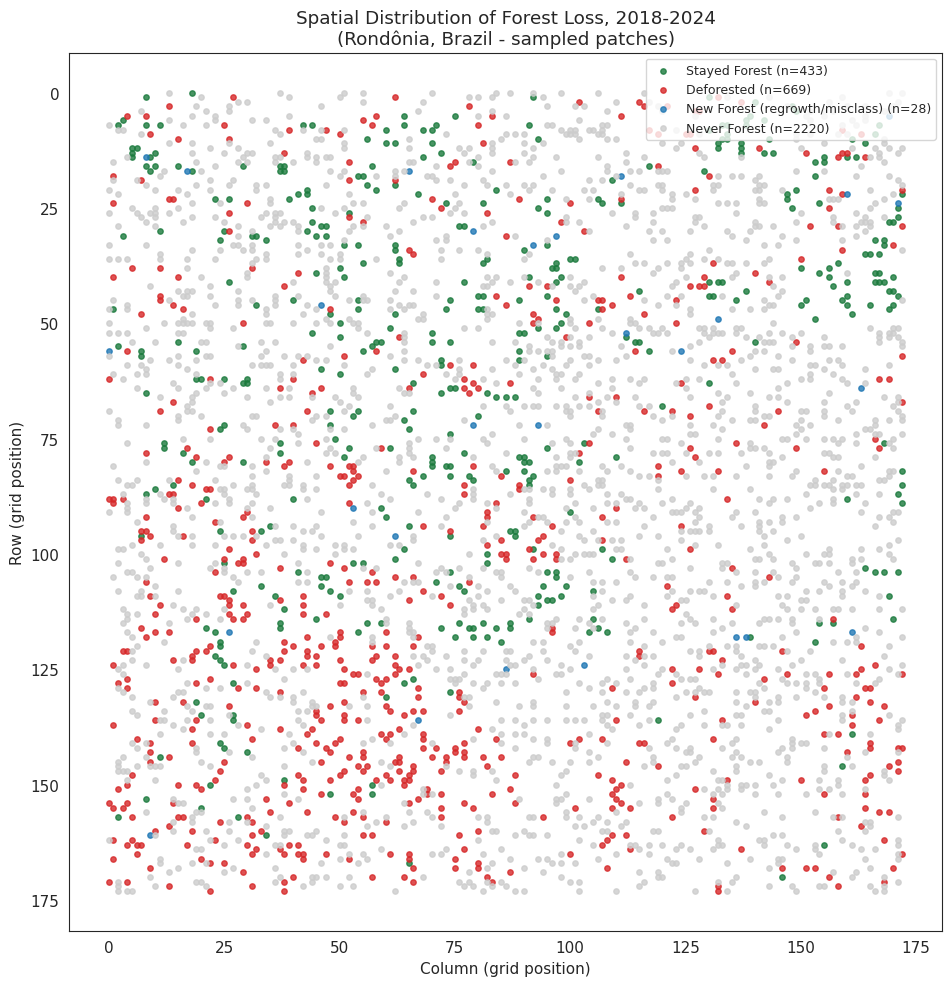

In [18]:
import matplotlib.pyplot as plt

categories, rows, cols = [], [], []
for pos in lookup_2018:
    row, col = pos
    c18, c24 = lookup_2018[pos], lookup_2024[pos]
    if c18 == forest_idx and c24 == forest_idx:
        cat = 'Stayed Forest'
    elif c18 == forest_idx and c24 != forest_idx:
        cat = 'Deforested'
    elif c18 != forest_idx and c24 == forest_idx:
        cat = 'New Forest (regrowth/misclass)'
    else:
        cat = 'Never Forest'
    categories.append(cat)
    rows.append(row)
    cols.append(col)

color_map = {
    'Stayed Forest': '#1a7a3c', 'Deforested': '#d62728',
    'New Forest (regrowth/misclass)': '#1f77b4', 'Never Forest': '#cccccc'
}

fig, ax = plt.subplots(figsize=(10, 10))
for cat, color in color_map.items():
    idx = [i for i, c in enumerate(categories) if c == cat]
    if idx:
        ax.scatter([cols[i] for i in idx], [rows[i] for i in idx],
                   c=color, label=f"{cat} (n={len(idx)})", s=15, alpha=0.8)

ax.invert_yaxis()
ax.set_xlabel('Column (grid position)')
ax.set_ylabel('Row (grid position)')
ax.set_title('Spatial Distribution of Forest Loss, 2018-2024\n(Rondônia, Brazil - sampled patches)')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('deforestation_map.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 16. Validation Against Global Forest Watch

Queries the Hansen Global Forest Change dataset (the basis of Global Forest Watch's published
tree-cover-loss statistics) for the same study area and time period, as an independent
validation of our model's detections.

In [19]:
hansen = ee.Image('UMD/hansen/global_forest_change_2025_v1_13')
loss_band = hansen.select('lossyear')
treecover2000 = hansen.select('treecover2000')
forest_mask = treecover2000.gt(30)  # GFW's standard >30% canopy threshold

loss_2018_2024 = loss_band.gte(18).And(loss_band.lte(24)).And(forest_mask)
loss_area = loss_2018_2024.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=30, maxPixels=1e9
)
total_forest_area = forest_mask.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=aoi, scale=30, maxPixels=1e9
)

gfw_loss_pct = loss_area.getInfo()['lossyear'] / total_forest_area.getInfo()['treecover2000'] * 100
print(f"GFW-reported forest loss (2018-2024): {gfw_loss_pct:.2f}%")
print(f"Our model's detected rate: {deforestation_rate:.1f}%")
print(f"Overestimate factor: {deforestation_rate / gfw_loss_pct:.1f}x")

GFW-reported forest loss (2018-2024): 6.91%
Our model's detected rate: 60.7%
Overestimate factor: 8.8x


## 17. Final Summary

In [20]:
final_summary = {
    'model_test_accuracy_eurosat': 0.98,
    'model_val_accuracy': checkpoint['val_accuracy'],
    'our_detected_deforestation_rate_pct': deforestation_rate,
    'gfw_reported_deforestation_rate_pct': gfw_loss_pct,
    'overestimate_factor': deforestation_rate / gfw_loss_pct,
    'aoi_bounds': [-63.0, -10.5, -62.0, -9.5],
    'study_region': 'Rondônia, Brazil',
    'time_period': '2018-2024',
    'sample_size_per_year': len(patches_2018)
}

with open('/content/drive/MyDrive/deforestation_project/final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print(json.dumps(final_summary, indent=2))

{
  "model_test_accuracy_eurosat": 0.98,
  "model_val_accuracy": 0.9855555555555555,
  "our_detected_deforestation_rate_pct": 60.70780399274047,
  "gfw_reported_deforestation_rate_pct": 6.906848409273068,
  "overestimate_factor": 8.789508672469887,
  "aoi_bounds": [
    -63.0,
    -10.5,
    -62.0,
    -9.5
  ],
  "study_region": "Rond\u00f4nia, Brazil",
  "time_period": "2018-2024",
  "sample_size_per_year": 3350
}


## 18. Investigating and Correcting the SeaLake Bias

The classifier showed a strong, implausible bias toward predicting "SeaLake" for non-forest
land in this region (58.8% of 2018 patches, 79.2% of 2024 patches). This section inspects why,
tests a small manual correction, and checks whether it actually fixes the problem.

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np
import random
import json

# Reload the source images
with rasterio.open('/content/drive/MyDrive/deforestation_project/rondonia_2018.tif') as src:
    img_2018 = src.read()

# Rebuild the exact same random patch sample (same seed = same locations)
patch_size = 64

def extract_patches_random_sample(image_array, patch_size=64, n_samples=3350, seed=42):
    img = np.transpose(image_array, (1, 2, 0))
    h, w, c = img.shape
    n_rows_full = h // patch_size
    n_cols_full = w // patch_size
    all_positions = [(r, c) for r in range(n_rows_full) for c in range(n_cols_full)]
    rng = random.Random(seed)
    sampled_positions = rng.sample(all_positions, n_samples)
    patches = []
    for (row, col) in sampled_positions:
        y0, x0 = row * patch_size, col * patch_size
        patches.append(img[y0:y0+patch_size, x0:x0+patch_size, :])
    return patches, sampled_positions

patches_2018, positions_2018 = extract_patches_random_sample(img_2018, n_samples=3350, seed=42)

def global_percentile_stretch(patch, low_pct=2, high_pct=98):
    flat = patch.astype(np.float32).flatten()
    low = np.percentile(flat, low_pct)
    high = np.percentile(flat, high_pct)
    stretched = np.clip((patch.astype(np.float32) - low) / (high - low) * 255, 0, 255)
    return stretched.astype(np.uint8)

patches_2018_final = [global_percentile_stretch(p) for p in patches_2018]

# Reload the saved classification results (no need to reclassify)
with open('/content/drive/MyDrive/deforestation_project/results_2018.json', 'r') as f:
    results_2018 = json.load(f)

class_names = ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
               'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

print("Reloaded. Patches:", len(patches_2018_final), "| Results:", len(results_2018))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reloaded. Patches: 3350 | Results: 3350


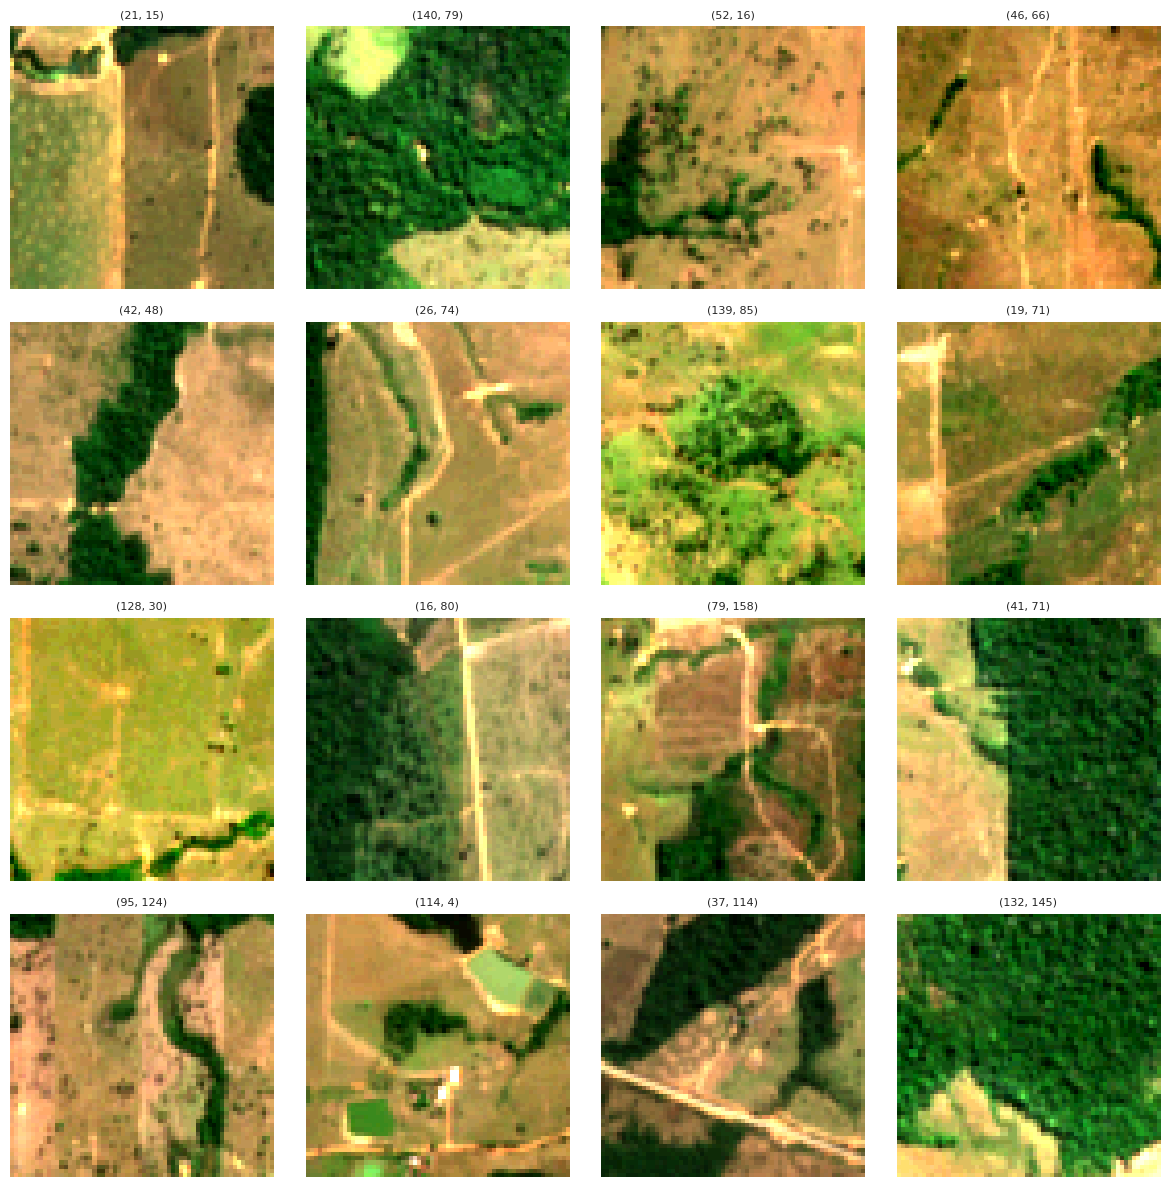

In [22]:
import matplotlib.pyplot as plt

sealake_idx = class_names.index('SeaLake')
sealake_positions = [(r, c) for r, c, pred in results_2018 if pred == sealake_idx]

# Rebuild patches at these specific positions for visual inspection
lookup_patch_2018 = {pos: patch for pos, patch in zip(positions_2018, patches_2018_final)}

sample_check = sealake_positions[:16]
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, pos in zip(axes.flat, sample_check):
    ax.imshow(lookup_patch_2018[pos])
    ax.set_title(f"{pos}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sealake_check.png', dpi=150)
plt.show()

In [23]:
label_map = {
    (21,15): 'AnnualCrop', (140,79): 'Forest', (52,16): 'PermanentCrop', (46,66): 'PermanentCrop',
    (42,48): 'River', (26,74): 'AnnualCrop', (139,85): 'Forest', (19,71): 'River',
    (128,30): 'AnnualCrop', (16,80): 'Highway', (79,158): 'AnnualCrop', (41,71): 'Forest',
    (95,124): 'River', (114,4): 'PermanentCrop', (37,114): 'Highway', (132,145): 'Forest'
}

correction_patches = [lookup_patch_2018[pos] for pos in label_map]
correction_labels = [class_names.index(cls) for cls in label_map.values()]

print(f"Built correction set: {len(correction_patches)} labeled examples")
print("Class distribution:", {cls: list(label_map.values()).count(cls) for cls in set(label_map.values())})

Built correction set: 16 labeled examples
Class distribution: {'AnnualCrop': 4, 'Highway': 2, 'PermanentCrop': 3, 'Forest': 4, 'River': 3}


### 18.1 Manual Correction

Visual inspection of 16 "SeaLake" predictions showed none were actually water. They were
forest, cropland, and highway, misclassified because the model never encountered comparable
land cover during training on European imagery alone. Each patch was manually labeled with
its true class and used to fine-tune only the model's final layer, keeping all other layers
frozen to avoid erasing what it learned from the full EuroSAT training set.

In [24]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as Fnn

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Reload the original trained model fresh
model = models.resnet50(weights=None)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
checkpoint = torch.load('/content/drive/MyDrive/best_model.pth', map_location=torch.device(device))
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

# Freeze everything except the final layer
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

def preprocess_batch_fast(patches_batch):
    arr = np.stack(patches_batch).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(0, 3, 1, 2)
    tensor = Fnn.interpolate(tensor, size=(224, 224), mode='bilinear', align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    return ((tensor - mean) / std).to(device)

correction_tensor = preprocess_batch_fast(correction_patches)
correction_label_tensor = torch.tensor(correction_labels).to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(correction_tensor)
    loss = criterion(outputs, correction_label_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        acc = (outputs.argmax(1) == correction_label_tensor).float().mean().item()
        print(f"Epoch {epoch}: loss={loss.item():.4f}, accuracy on correction set={acc:.2f}")

torch.save({'model_state_dict': model.state_dict()}, '/content/drive/MyDrive/deforestation_project/best_model_corrected.pth')
print("Saved corrected model.")

Epoch 0: loss=2.1393, accuracy on correction set=0.38
Epoch 5: loss=2.0737, accuracy on correction set=0.38
Epoch 10: loss=2.0098, accuracy on correction set=0.38
Epoch 15: loss=1.9478, accuracy on correction set=0.38
Saved corrected model.


In [25]:
model.eval()
with torch.no_grad():
    outputs = model(correction_tensor)
    predicted = outputs.argmax(1)

for i, (pos, true_label) in enumerate(zip(label_map.keys(), correction_labels)):
    pred_label = predicted[i].item()
    status = "correct" if pred_label == true_label else "WRONG"
    print(f"{pos}: true={class_names[true_label]}, predicted={class_names[pred_label]} [{status}]")

(21, 15): true=AnnualCrop, predicted=PermanentCrop [WRONG]
(140, 79): true=Forest, predicted=Forest [correct]
(52, 16): true=PermanentCrop, predicted=HerbaceousVegetation [WRONG]
(46, 66): true=PermanentCrop, predicted=HerbaceousVegetation [WRONG]
(42, 48): true=River, predicted=HerbaceousVegetation [WRONG]
(26, 74): true=AnnualCrop, predicted=AnnualCrop [correct]
(139, 85): true=Forest, predicted=Forest [correct]
(19, 71): true=River, predicted=PermanentCrop [WRONG]
(128, 30): true=AnnualCrop, predicted=PermanentCrop [WRONG]
(16, 80): true=Highway, predicted=PermanentCrop [WRONG]
(79, 158): true=AnnualCrop, predicted=PermanentCrop [WRONG]
(41, 71): true=Forest, predicted=Forest [correct]
(95, 124): true=River, predicted=HerbaceousVegetation [WRONG]
(114, 4): true=PermanentCrop, predicted=Pasture [WRONG]
(37, 114): true=Highway, predicted=Highway [correct]
(132, 145): true=Forest, predicted=Forest [correct]


In [26]:
def classify_patches_sampled(patches, positions, model, batch_size=64):
    results = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(patches), batch_size):
            batch_patches = patches[i:i+batch_size]
            batch_positions = positions[i:i+batch_size]
            batch_tensors = preprocess_batch_fast(batch_patches)
            outputs = model(batch_tensors)
            _, predicted = torch.max(outputs, 1)
            for (row, col), pred in zip(batch_positions, predicted.cpu().numpy()):
                results.append((row, col, int(pred)))
    return results

print("Reclassifying full 2018 sample with corrected model...")
results_2018_corrected = classify_patches_sampled(patches_2018_final, positions_2018, model)

from collections import Counter
preds_corrected = [pred for r, c, pred in results_2018_corrected]
print("\nCorrected model — 2018 prediction distribution:")
for idx, count in sorted(Counter(preds_corrected).items()):
    print(f"  {class_names[idx]}: {count} ({count/len(preds_corrected)*100:.1f}%)")

Reclassifying full 2018 sample with corrected model...

Corrected model — 2018 prediction distribution:
  AnnualCrop: 476 (14.2%)
  Forest: 872 (26.0%)
  HerbaceousVegetation: 241 (7.2%)
  Highway: 150 (4.5%)
  Industrial: 51 (1.5%)
  Pasture: 456 (13.6%)
  PermanentCrop: 755 (22.5%)
  Residential: 86 (2.6%)
  River: 230 (6.9%)
  SeaLake: 33 (1.0%)


In [27]:
with open('/content/drive/MyDrive/deforestation_project/results_2018_corrected.json', 'w') as f:
    json.dump(results_2018_corrected, f)
print("Saved.")

Saved.


In [28]:
with rasterio.open('/content/drive/MyDrive/deforestation_project/rondonia_2024.tif') as src:
    img_2024 = src.read()

patches_2024, positions_2024 = extract_patches_random_sample(img_2024, n_samples=3350, seed=42)
patches_2024_final = [global_percentile_stretch(p) for p in patches_2024]

print("Reclassifying 2024 with corrected model...")
results_2024_corrected = classify_patches_sampled(patches_2024_final, positions_2024, model)

preds_2024_corrected = [pred for r, c, pred in results_2024_corrected]
print("\nCorrected model — 2024 prediction distribution:")
for idx, count in sorted(Counter(preds_2024_corrected).items()):
    print(f"  {class_names[idx]}: {count} ({count/len(preds_2024_corrected)*100:.1f}%)")

with open('/content/drive/MyDrive/deforestation_project/results_2024_corrected.json', 'w') as f:
    json.dump(results_2024_corrected, f)
print("Saved.")

Reclassifying 2024 with corrected model...

Corrected model — 2024 prediction distribution:
  AnnualCrop: 1208 (36.1%)
  Forest: 389 (11.6%)
  HerbaceousVegetation: 801 (23.9%)
  Highway: 87 (2.6%)
  Industrial: 25 (0.7%)
  Pasture: 143 (4.3%)
  PermanentCrop: 121 (3.6%)
  Residential: 125 (3.7%)
  River: 366 (10.9%)
  SeaLake: 85 (2.5%)
Saved.


### 18.2 Results After Correction

The SeaLake collapse was fixed (58.8% -> 1.0% of 2018 patches), but the overall deforestation
rate only dropped modestly (60.7% -> 56.4%), still roughly 8x above Global Forest Watch's
6.91%. This points to a second issue: 640m patches are far coarser than GFW's 30m pixel
resolution, so a mostly-forest patch with a small cleared section still gets labeled by its
majority class, likely inflating detected change independent of the bias fixed above.

In [29]:
lookup_2018_corrected = {(r, c): pred for r, c, pred in results_2018_corrected}
lookup_2024_corrected = {(r, c): pred for r, c, pred in results_2024_corrected}

forest_idx = class_names.index('Forest')
was_forest_2018_c, still_forest_2024_c, deforested_c = 0, 0, 0
transitions_c = {}

for pos in lookup_2018_corrected:
    c18, c24 = lookup_2018_corrected[pos], lookup_2024_corrected[pos]
    if c18 == forest_idx:
        was_forest_2018_c += 1
        if c24 == forest_idx:
            still_forest_2024_c += 1
        else:
            deforested_c += 1
            new_class = class_names[c24]
            transitions_c[new_class] = transitions_c.get(new_class, 0) + 1

deforestation_rate_corrected = deforested_c / was_forest_2018_c * 100

print(f"Forest in 2018: {was_forest_2018_c}")
print(f"Still Forest in 2024: {still_forest_2024_c}")
print(f"Deforested: {deforested_c}")
print(f"Corrected deforestation rate: {deforestation_rate_corrected:.1f}%")
print(f"\nWhat deforested patches became (corrected model):")
for cls, count in sorted(transitions_c.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {count} ({count/deforested_c*100:.1f}%)")

print(f"\nGFW reported rate: 6.91%")
print(f"Corrected model overestimate factor: {deforestation_rate_corrected / 6.91:.2f}x")

Forest in 2018: 872
Still Forest in 2024: 380
Deforested: 492
Corrected deforestation rate: 56.4%

What deforested patches became (corrected model):
  AnnualCrop: 146 (29.7%)
  HerbaceousVegetation: 118 (24.0%)
  Residential: 105 (21.3%)
  River: 67 (13.6%)
  Highway: 22 (4.5%)
  SeaLake: 14 (2.8%)
  PermanentCrop: 10 (2.0%)
  Pasture: 8 (1.6%)
  Industrial: 2 (0.4%)

GFW reported rate: 6.91%
Corrected model overestimate factor: 8.17x


### 18.3 Visualizing the Correction

Comparing the original model, the corrected model, and Global Forest Watch's ground truth
directly, and visualizing how the 2018 prediction distribution changed after correction.

In [30]:
import json

with open('/content/drive/MyDrive/deforestation_project/results_2024.json', 'r') as f:
    results_2024 = json.load(f)

lookup_2018 = {(r, c): pred for r, c, pred in results_2018}
lookup_2024 = {(r, c): pred for r, c, pred in results_2024}

forest_idx = class_names.index('Forest')
was_forest_2018, deforested = 0, 0
for pos in lookup_2018:
    if lookup_2018[pos] == forest_idx:
        was_forest_2018 += 1
        if lookup_2024[pos] != forest_idx:
            deforested += 1

deforestation_rate = deforested / was_forest_2018 * 100
gfw_loss_pct = 6.91  # already computed earlier via Earth Engine / Hansen dataset

print(f"Original deforestation rate: {deforestation_rate:.1f}%")
print(f"GFW rate: {gfw_loss_pct}%")

Original deforestation rate: 60.7%
GFW rate: 6.91%


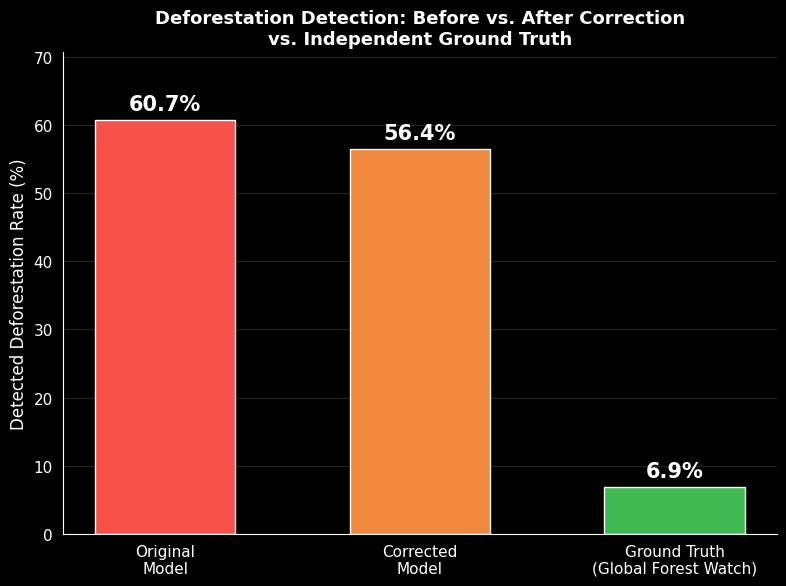

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6), facecolor='black')
ax.set_facecolor('black')

labels = ['Original\nModel', 'Corrected\nModel', 'Ground Truth\n(Global Forest Watch)']
values = [deforestation_rate, deforestation_rate_corrected, gfw_loss_pct]
colors = ['#f85149', '#f0883e', '#3fb950']

bars = ax.bar(labels, values, color=colors, width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val:.1f}%',
             ha='center', fontsize=15, fontweight='bold', color='white')

ax.set_ylabel('Detected Deforestation Rate (%)', fontsize=12, color='white')
ax.set_title('Deforestation Detection: Before vs. After Correction\nvs. Independent Ground Truth',
             fontsize=13, fontweight='bold', color='white')
ax.set_ylim(0, max(values) + 10)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.15, color='white')

plt.tight_layout()
plt.savefig('deforestation_comparison.png', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

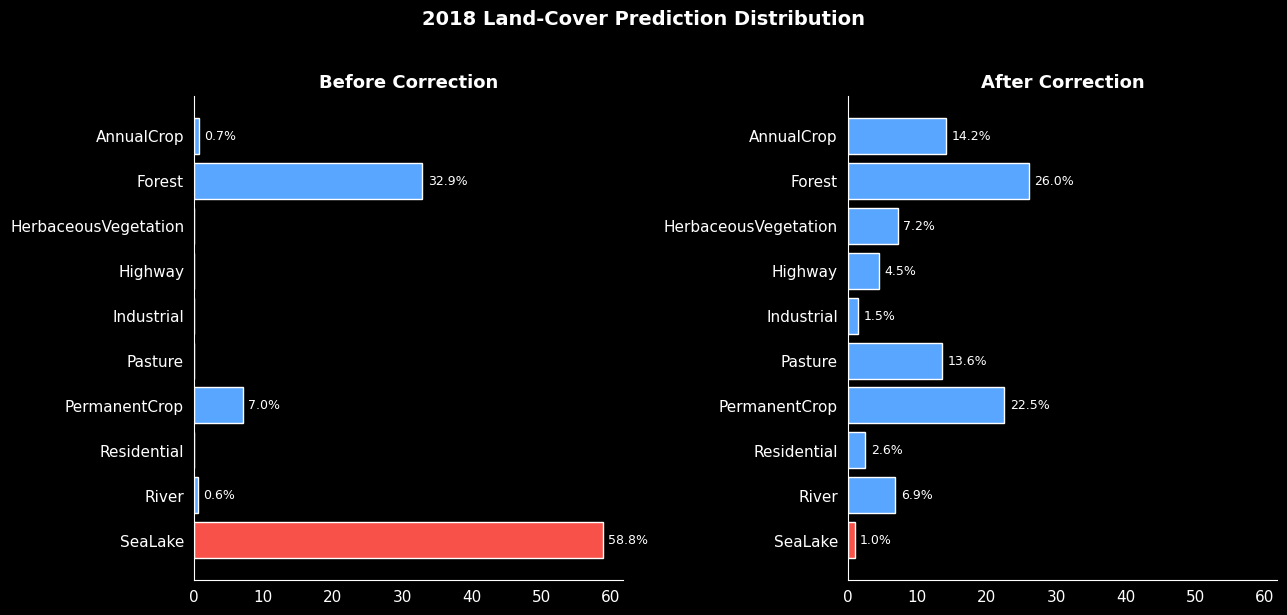

In [32]:
from collections import Counter

preds_before = [pred for r, c, pred in results_2018]
preds_after = [pred for r, c, pred in results_2018_corrected]

before_pct = {class_names[i]: Counter(preds_before).get(i, 0)/len(preds_before)*100 for i in range(10)}
after_pct = {class_names[i]: Counter(preds_after).get(i, 0)/len(preds_after)*100 for i in range(10)}

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, facecolor='black')

for ax, data, title in zip(axes, [before_pct, after_pct], ['Before Correction', 'After Correction']):
    ax.set_facecolor('black')
    classes = list(data.keys())
    vals = list(data.values())
    bar_colors = ['#f85149' if c == 'SeaLake' else '#58a6ff' for c in classes]
    ax.barh(classes, vals, color=bar_colors)
    ax.set_title(title, fontsize=13, fontweight='bold', color='white')
    ax.invert_yaxis()
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('white')
    ax.tick_params(colors='white')
    for i, v in enumerate(vals):
        if v > 0.3:
            ax.text(v + 0.8, i, f'{v:.1f}%', va='center', fontsize=9, color='white')

fig.suptitle('2018 Land-Cover Prediction Distribution', fontsize=14, fontweight='bold', y=1.02, color='white')
plt.tight_layout()
plt.savefig('distribution_before_after.png', dpi=300, bbox_inches='tight', facecolor='black')
plt.show()